In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

url_data = "https://docs.google.com/spreadsheets/d/1hmH7aVkADkHk3Un8rxGYFb4Xail0sWbK/export?format=csv"
df = pd.read_csv(url_data)
df["sales_date"] = pd.to_datetime(df["sales_date"])

print("Data berhasil di-load!")
print("Jumlah baris dan kolom:", df.shape)
df.head()


Data berhasil di-load!
Jumlah baris dan kolom: (10000, 16)


,sales_date,order_id,customer_name,customer_address,product_name,category,unit,price,quantity,order_type,distance_km,discount,total,shipping_fee,total_sales,status
0,2025-07-17,RMP00001,Customer_1198,"Kecamatan Cicalengka, Kabupaten Bandung",Bunga Lawang (Pekak),Rempah Kering & Bumbu Dapur,50 gr,9000,1,Beli di Toko,0,0,9000,0,9000,completed
1,2025-09-11,RMP00002,Customer_3969,"Kecamatan Gedebage, Kota Bandung",Kencur,Rempah & Sayuran Segar,250 gr,8000,1,Beli di Toko,0,0,8000,0,8000,completed
2,2025-11-15,RMP00003,Customer_575,"Kecamatan Padalarang, Kabupaten Bandung Barat",Paket Bumbu Gule Sapi,Paket Bumbu Instan,1 paket,15000,2,Diantar (Aplikasi Toko),"14,2",0,30000,25000,55000,completed
3,2025-06-06,RMP00004,Customer_1394,"Kecamatan Cisarua, Kabupaten Bandung Barat",Paket Bumbu Soto Betawi,Paket Bumbu Instan,1 paket,22000,1,Beli di Toko,0,0,22000,0,22000,completed
4,2025-12-13,RMP00005,Customer_1382,"Kecamatan Sukajadi, Kota Bandung",Paket Bumbu Woku Manado,Paket Bumbu Instan,1 paket,20000,1,Diantar (Aplikasi Toko),"1,5",0,20000,0,20000,completed


--- Cleaning Data ---

Check Data Type :

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[us]
 1   order_id          10000 non-null  str           
 2   customer_name     10000 non-null  str           
 3   customer_address  10000 non-null  str           
 4   product_name      10000 non-null  str           
 5   category          10000 non-null  str           
 6   unit              10000 non-null  str           
 7   price             10000 non-null  int64         
 8   quantity          10000 non-null  int64         
 9   order_type        10000 non-null  str           
 10  distance_km       10000 non-null  str           
 11  discount          10000 non-null  str           
 12  total             10000 non-null  int64         
 13  shipping_fee      10000 non-null  int64         
 14  total_sales       10000 non-null  

Karna 'Discount' nya berupa 'str', maka kita ganti dulu :

In [3]:
df['discount'] = df['discount'].str.replace(',', '.').astype(float)

In [4]:
df['discount'].dtype

dtype('float64')

---
## Soal 1: Filter Pakai `.loc[]`

Pakai `.loc[]`, ambil transaksi dari kategori `"Rempah & Sayuran Segar"` yang jumlah pembeliannya (`quantity`) 4 atau lebih. Tampilkan cuma kolom `order_id`, `product_name`, `quantity`, dan `total_sales`. Ada berapa transaksi yang memenuhi kriteria ini?


In [5]:
# filter loc[]

df.loc[(df['category'] == "Rempah & Sayuran Segar") & (df['quantity'] >=4)]

,sales_date,order_id,customer_name,customer_address,product_name,category,unit,price,quantity,order_type,distance_km,discount,total,shipping_fee,total_sales,status
48,2025-01-14,RMP00049,Customer_2968,"Kecamatan Ngamprah, Kabupaten Bandung Barat",Bawang Prei,Rempah & Sayuran Segar,250 gr,6000,4,Beli di Toko,0,0.10,21600,0,21600,refund
81,2025-04-08,RMP00082,Customer_1889,"Kecamatan Banjaran, Kabupaten Bandung",Bawang Prei,Rempah & Sayuran Segar,250 gr,6000,4,Beli di Toko,0,0.05,22800,0,22800,completed
93,2025-03-27,RMP00094,Customer_3591,"Kecamatan Cidadap, Kota Bandung",Lengkuas,Rempah & Sayuran Segar,250 gr,6000,4,Diantar (Aplikasi Toko),"3,2",0.00,24000,9000,33000,completed
94,2025-11-22,RMP00095,Customer_988,"Kecamatan Lembang, Kabupaten Bandung Barat",Bawang Prei,Rempah & Sayuran Segar,250 gr,6000,5,Diantar (Aplikasi Toko),"13,1",0.00,30000,25000,55000,completed
119,2025-05-21,RMP00120,Customer_2329,"Kecamatan Dayeuhkolot, Kabupaten Bandung",Bawang Prei,Rempah & Sayuran Segar,250 gr,6000,5,Diantar (Aplikasi Toko),"10,1",0.00,30000,18000,48000,completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9766,2025-12-19,RMP09767,Customer_3537,"Kecamatan Sumur Bandung, Kota Bandung",Serai,Rempah & Sayuran Segar,250 gr,5000,5,Beli di Toko,0,0.10,22500,0,22500,completed
9776,2025-10-27,RMP09777,Customer_3198,"Kecamatan Soreang, Kabupaten Bandung",Cabai Rawit Hijau,Rempah & Sayuran Segar,250 gr,16000,4,Beli di Toko,0,0.00,64000,0,64000,completed
9863,2025-08-02,RMP09864,Customer_2002,"Kecamatan Antapani, Kota Bandung",Daun Kemangi,Rempah & Sayuran Segar,100 gr,4000,5,Beli di Toko,0,0.00,20000,0,20000,completed
9867,2025-04-21,RMP09868,Customer_4482,"Kecamatan Cimahi Utara, Kota Cimahi",Daun Jeruk,Rempah & Sayuran Segar,50 gr,3500,5,Beli di Toko,0,0.00,17500,0,17500,completed


In [6]:
# Tampilkan cuma kolom `order_id`, `product_name`, `quantity`, dan `total_sales`.

df.loc[:,[
    'order_id',
    'product_name',
    'quantity',
    'total_sales'
]]

,order_id,product_name,quantity,total_sales
0,RMP00001,Bunga Lawang (Pekak),1,9000
1,RMP00002,Kencur,1,8000
2,RMP00003,Paket Bumbu Gule Sapi,2,55000
3,RMP00004,Paket Bumbu Soto Betawi,1,22000
4,RMP00005,Paket Bumbu Woku Manado,1,20000
...,...,...,...,...
9995,RMP09996,Paket Bumbu Nasi Goreng,2,30600
9996,RMP09997,Bunga Lawang (Pekak),3,59000
9997,RMP09998,Paket Bumbu Tongseng,1,32000
9998,RMP09999,Paket Bumbu Rica-Rica,1,57000


In [7]:
# Ada berapa transaksi yang memenuhi kriteria ini?

print("Jumlah Transaksi : ",len(df))

Jumlah Transaksi :  10000


---
## Soal 2: Filter Rentang Harga Pakai `.between()`

Khusus untuk transaksi berstatus `"completed"`, berapa banyak transaksi yang produknya punya `price` di rentang Rp 10.000 sampai Rp 20.000 (inklusif)?


In [8]:
transaksi_completed = df.loc[
    (df['status'] == 'completed') &
    (df['price'].between(10000, 20000))
]

In [9]:
# tampilkan Jumlah Transaksi nya
print("Jumlah Transaksi Completed : ", len(transaksi_completed),"Transaksi")

Jumlah Transaksi Completed :  4418 Transaksi


---
## Soal 3: Kategorisasi Ongkir Pakai `.apply()` + `lambda`

Buat kolom baru bernama `jenis_ongkir`, isinya `"Gratis Ongkir"` kalau `shipping_fee` sama dengan 0, dan `"Berbayar"` kalau lebih dari 0. Pakai `.apply()` dengan `lambda`. Setelah itu, hitung ada berapa banyak transaksi di masing-masing jenis ongkir.


In [10]:
# membuat kolom baru, dan logic apply() and lambda()

df['jenis_ongkir'] = df['shipping_fee'].apply(lambda x: "berbayar" 
if x > 0 
else 'gratis ongkir')
df.head()

,sales_date,order_id,customer_name,customer_address,product_name,category,unit,price,quantity,order_type,distance_km,discount,total,shipping_fee,total_sales,status,jenis_ongkir
0,2025-07-17,RMP00001,Customer_1198,"Kecamatan Cicalengka, Kabupaten Bandung",Bunga Lawang (Pekak),Rempah Kering & Bumbu Dapur,50 gr,9000,1,Beli di Toko,0,0.0,9000,0,9000,completed,gratis ongkir
1,2025-09-11,RMP00002,Customer_3969,"Kecamatan Gedebage, Kota Bandung",Kencur,Rempah & Sayuran Segar,250 gr,8000,1,Beli di Toko,0,0.0,8000,0,8000,completed,gratis ongkir
2,2025-11-15,RMP00003,Customer_575,"Kecamatan Padalarang, Kabupaten Bandung Barat",Paket Bumbu Gule Sapi,Paket Bumbu Instan,1 paket,15000,2,Diantar (Aplikasi Toko),"14,2",0.0,30000,25000,55000,completed,berbayar
3,2025-06-06,RMP00004,Customer_1394,"Kecamatan Cisarua, Kabupaten Bandung Barat",Paket Bumbu Soto Betawi,Paket Bumbu Instan,1 paket,22000,1,Beli di Toko,0,0.0,22000,0,22000,completed,gratis ongkir
4,2025-12-13,RMP00005,Customer_1382,"Kecamatan Sukajadi, Kota Bandung",Paket Bumbu Woku Manado,Paket Bumbu Instan,1 paket,20000,1,Diantar (Aplikasi Toko),"1,5",0.0,20000,0,20000,completed,gratis ongkir


In [11]:
# hitung ada berapa banyak transaksi di masing-masing jenis ongkir

df['jenis_ongkir'].value_counts()

# --> ambil kolom 'jenis_ongkir', lalu hitung transaksi dri masing-masing kategori 'jenis_ongkir'

jenis_ongkir
gratis ongkir    5939
berbayar         4061
Name: count, dtype: int64

---
## Soal 4: Deteksi Outlier Jarak Antar (Metode IQR)

Khusus untuk transaksi berstatus `"completed"`, deteksi outlier pada kolom `distance_km` pakai metode IQR (sama kayak yang dicontohkan di kelas untuk `total_sales`). Kerjakan langkah berikut:

1. Hitung Q1, Q3, dan IQR dari `distance_km`.
2. Hitung batas atas (`Q3 + 1.5 × IQR`).
3. Filter transaksi yang `distance_km`-nya melebihi batas atas tersebut, simpan ke variabel baru.
4. Tampilkan jumlah transaksi outlier tersebut, dan cek juga: apakah semuanya berasal dari `order_type` "Diantar (Aplikasi Toko)"? (masuk akal atau enggak kalau iya?)


In [ ]:
# 1. Hitung Q1, Q3, IQR dari distance_km (khusus completed)
df["distance_km"] = pd.to_numeric(df["distance_km"], errors="coerce")

transaksi_selesai = df[
    (df["status"] == "completed") &
    (df["order_type"] == "Diantar (Aplikasi Toko)") &
    (df["distance_km"].notna())
].copy()

print("Jumlah data dipakai:", len(transaksi_selesai))

Q1 = transaksi_selesai["distance_km"].quantile(0.25)
Q3 = transaksi_selesai["distance_km"].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Batas atas outlier: {batas_atas:,.2f}")

outlier_jarak = transaksi_selesai[transaksi_selesai["distance_km"] > batas_atas]
print("Jumlah transaksi outlier:", len(outlier_jarak))



Jumlah data dipakai: 390
Q1: 5.00 | Q3: 13.00 | IQR: 8.00
Batas atas outlier: 25.00
Jumlah transaksi outlier: 2


,sales_date,order_id,kecamatan,distance_km
4564,2025-01-29,RMP04565,"Kecamatan Ciwidey, Kabupaten Bandung",26.0
9081,2025-02-02,RMP09082,"Kecamatan Ciwidey, Kabupaten Bandung",26.0


0.25 / 0.75   ->   Q1 / Q3   ->   batas bawah / batas atas
(persentase)      (nilai data)    (pagar, hasil rumus)

perkiraan angka: (Q1 = 5, Q3 = 13, IQR = 8)

batas_bawah = 5 - 1.5 × 8  = -7
batas_atas  = 13 + 1.5 × 8 = 25

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_10856\3029142704.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(transaksi_selesai["distance_km"].dropna(), vert=False, showfliers=True)


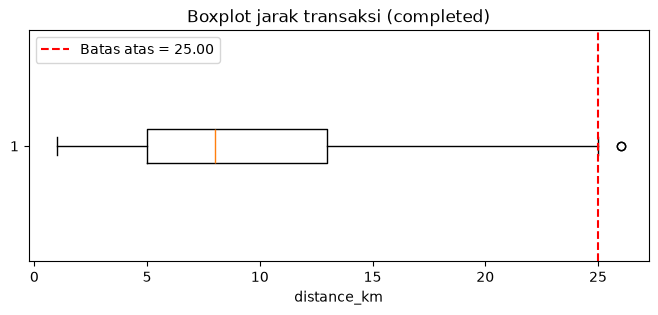

In [25]:

plt.figure(figsize=(8, 3))
plt.boxplot(transaksi_selesai["distance_km"].dropna(), vert=False, showfliers=True)
plt.axvline(batas_atas, color="red", linestyle="--", label=f"Batas atas = {batas_atas:,.2f}")
plt.xlabel("distance_km")
plt.title("Boxplot jarak transaksi (completed)")
plt.legend()
plt.show()

In [27]:
print(df["order_type"].value_counts())
print(df["jenis_ongkir"].value_counts())

print(df.groupby("order_type")["distance_km"].describe())

order_type
Beli di Toko               5537
Diantar (Aplikasi Toko)    4463
Name: count, dtype: int64
jenis_ongkir
gratis ongkir    5939
berbayar         4061
Name: count, dtype: int64
                          count      mean       std  min  25%  50%   75%   max
order_type                                                                    
Beli di Toko             5537.0  0.000000  0.000000  0.0  0.0  0.0   0.0   0.0
Diantar (Aplikasi Toko)   430.0  9.097674  5.817324  1.0  5.0  8.0  13.0  26.0


In [32]:
# 2. Hitung batas atas outlier

print(f"Batas atas outlier: {batas_atas:,.0f}")

Batas atas outlier: 25


In [33]:
# 3. Filter transaksi yang distance_km-nya melebihi batas atas

outlier_jarak = transaksi_selesai[transaksi_selesai["distance_km"] > batas_atas]
print("Jumlah transaksi outlier:", len(outlier_jarak))

outlier_jarak[["sales_date", "order_id", "kecamatan", "distance_km"]]

Jumlah transaksi outlier: 2


,sales_date,order_id,kecamatan,distance_km
4564,2025-01-29,RMP04565,"Kecamatan Ciwidey, Kabupaten Bandung",26.0
9081,2025-02-02,RMP09082,"Kecamatan Ciwidey, Kabupaten Bandung",26.0


In [30]:
# 4. Tampilkan jumlah outlier, dan cek distribusi order_type-nya

print(outlier_jarak["order_type"].value_counts())

order_type
Diantar (Aplikasi Toko)    2
Name: count, dtype: int64


---
## Soal 5: Ranking Kecamatan Berdasarkan Pendapatan

Teh Rina mau tau kecamatan mana yang paling potensial buat dijadikan lokasi promosi khusus. Kerjakan langkah berikut:

1. Ambil kecamatan dari `customer_address` (pakai cara yang sama seperti di kelas).
2. Khusus transaksi `"completed"`, kelompokkan berdasarkan kecamatan, lalu hitung sekaligus **total pendapatan**, **jumlah transaksi**, dan **rata-rata pendapatan per transaksi** pakai `.agg()` dalam satu langkah.
3. Urutkan berdasarkan total pendapatan, tampilkan 5 kecamatan teratas.


In [17]:
# 1. Ambil kecamatan dari `customer_address`

df["kecamatan"] = df["customer_address"]

df.kecamatan

0             Kecamatan Cicalengka, Kabupaten Bandung
1                    Kecamatan Gedebage, Kota Bandung
2       Kecamatan Padalarang, Kabupaten Bandung Barat
3          Kecamatan Cisarua, Kabupaten Bandung Barat
4                    Kecamatan Sukajadi, Kota Bandung
                            ...                      
9995          Kecamatan Cicalengka, Kabupaten Bandung
9996            Kecamatan Banjaran, Kabupaten Bandung
9997    Kecamatan Padalarang, Kabupaten Bandung Barat
9998            Kecamatan Cileunyi, Kabupaten Bandung
9999              Kecamatan Astanaanyar, Kota Bandung
Name: kecamatan, Length: 10000, dtype: str

In [18]:
# 2. Khusus transaksi `"completed"`, kelompokkan berdasarkan kecamatan,
# lalu hitung sekaligus **total pendapatan**, **jumlah transaksi**,
# dan **rata-rata pendapatan per transaksi** pakai `.agg()` dalam satu langkah.

transaksi_completed = df[df["status"] == "completed"].copy()

ringkasan_kecamatan = transaksi_completed.groupby("kecamatan")["total_sales"].agg(
    total_pendapatan="sum",
    jumlah_transaksi="count",
    avarage_pendapatan="mean"
).reset_index()

In [19]:
# 3. Urutkan berdasarkan total pendapatan, tampilkan 5 kecamatan teratas.

ringkasan_kecamatan.sort_values("total_pendapatan", ascending=False).head()


,kecamatan,total_pendapatan,jumlah_transaksi,avarage_pendapatan
22,"Kecamatan Majalaya, Kabupaten Bandung",14637150,334,43823.802395
23,"Kecamatan Ngamprah, Kabupaten Bandung Barat",14580950,347,42020.028818
17,"Kecamatan Ciwidey, Kabupaten Bandung",14363575,294,48855.697279
25,"Kecamatan Rancaekek, Kabupaten Bandung",13719775,318,43143.946541
5,"Kecamatan Banjaran, Kabupaten Bandung",13131175,287,45753.222997
